In [1]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

SEED = 0
np.random.seed(SEED); torch.manual_seed(SEED)
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

# ---------------- System configuration ----------------
N       = 64      # OFDM subcarriers
L       = 8       # number of channel taps (must be <= cyclic prefix length)
DECAY   = 0.5     # exponential PDP decay factor
SNR_TRAIN = (0, 30)               # dB range used for training
SNR_TEST  = np.arange(0, 31, 5)   # dB points for evaluation

Device: cpu


In [2]:
# Power-delay profile (normalised to unit total power)
pdp = np.exp(-DECAY * np.arange(L)); pdp /= pdp.sum()

# DFT matrix (N x L) mapping time-domain taps -> frequency response
F = np.fft.fft(np.eye(N))[:, :L]

# True frequency-domain covariance of the channel: R = F diag(pdp) F^H
R_hh = (F * pdp) @ F.conj().T

def cn(shape, rng=np.random):
    """Unit-variance circular complex Gaussian."""
    return (rng.randn(*shape) + 1j * rng.randn(*shape)) / np.sqrt(2)

def gen_channel(B):
    """B Rayleigh multipath channels -> frequency response, shape (B, N)."""
    h = cn((B, L)) * np.sqrt(pdp)
    return h @ F.T

def qpsk(B, n):
    bits = np.random.randint(0, 2, size=(B, n, 2))
    sym = ((1 - 2 * bits[..., 0]) + 1j * (1 - 2 * bits[..., 1])) / np.sqrt(2)
    return sym, bits

def simulate_pilot(B, snr_db):
    """One pilot OFDM symbol (all subcarriers are pilots) -> true H and LS estimate.
    snr_db: scalar or array of shape (B,1)."""
    sigma2 = 10 ** (-np.asarray(snr_db, dtype=float) / 10)
    H  = gen_channel(B)
    Xp = qpsk(B, N)[0]                                  # unit-power pilots
    Y  = H * Xp + np.sqrt(sigma2) * cn((B, N))
    H_ls = Y / Xp                                       # LS estimate
    return H, H_ls, sigma2

In [3]:
def ls_estimate(H_ls):
    return H_ls                       # LS = Y / X (already computed)

def mmse_estimate(H_ls, sigma2):
    """LMMSE: H = R (R + sigma2 I)^-1 H_ls  (needs R_hh and the SNR)."""
    W = R_hh @ np.linalg.inv(R_hh + sigma2 * np.eye(N))
    return H_ls @ W.T

def nmse(H, H_hat):
    return np.sum(np.abs(H - H_hat) ** 2) / np.sum(np.abs(H) ** 2)

def ber_qpsk(H_est, H_true, snr_db, n_blocks=None):
    """Send random QPSK data through H_true, equalise with H_est (ZF), return BER."""
    B = H_true.shape[0]
    sigma2 = 10 ** (-snr_db / 10)
    X, bits = qpsk(B, N)
    Y = H_true * X + np.sqrt(sigma2) * cn((B, N))
    X_hat = Y / H_est
    b_hat = np.stack([(X_hat.real < 0), (X_hat.imag < 0)], axis=-1).astype(int)
    return np.mean(b_hat != bits)

# Quick sanity check at 10 dB
H, H_ls, s2 = simulate_pilot(5000, 10)
print(f"10 dB  NMSE  LS: {10*np.log10(nmse(H, H_ls)):.2f} dB | "
      f"MMSE: {10*np.log10(nmse(H, mmse_estimate(H_ls, s2))):.2f} dB")

10 dB  NMSE  LS: -9.94 dB | MMSE: -19.14 dB


In [4]:
class CNNEstimator(nn.Module):
    def __init__(self, ch=64, n_layers=5, k=5):
        super().__init__()
        layers = [nn.Conv1d(3, ch, k, padding=k // 2, padding_mode="circular"), nn.ReLU()]
        for _ in range(n_layers - 2):
            layers += [nn.Conv1d(ch, ch, k, padding=k // 2, padding_mode="circular"), nn.ReLU()]
        layers += [nn.Conv1d(ch, 2, k, padding=k // 2, padding_mode="circular")]
        self.net = nn.Sequential(*layers)

    def forward(self, x):                 # x: (B, 3, N)
        return x[:, :2] + self.net(x)     # residual learning on the LS estimate

def make_input(H_ls, snr_db):
    """complex (B,N) LS estimate + SNR -> tensor (B,3,N)."""
    B = H_ls.shape[0]
    snr = np.broadcast_to(np.asarray(snr_db, dtype=float).reshape(-1, 1), (B, N)) / 30.0
    x = np.stack([H_ls.real, H_ls.imag, snr], axis=1)
    return torch.tensor(x, dtype=torch.float32)

def make_target(H):
    return torch.tensor(np.stack([H.real, H.imag], axis=1), dtype=torch.float32)

def to_complex(t):
    t = t.detach().cpu().numpy()
    return t[:, 0] + 1j * t[:, 1]

model = CNNEstimator().to(device)
n_params = sum(p.numel() for p in model.parameters())
print(f"CNN parameters: {n_params:,}")

CNN parameters: 63,298


In [5]:
EPOCHS, STEPS, BATCH = 30, 100, 256
opt   = torch.optim.Adam(model.parameters(), lr=1e-3)
sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=EPOCHS)
loss_fn = nn.MSELoss()
history = []

# fixed validation set at 10 dB
Hv, Hv_ls, _ = simulate_pilot(4000, 10)
xv, yv = make_input(Hv_ls, 10).to(device), make_target(Hv).to(device)

t0 = time.time()
for ep in range(EPOCHS):
    model.train(); run = 0.0
    for _ in range(STEPS):
        snr = np.random.uniform(*SNR_TRAIN, size=(BATCH, 1))
        H, H_ls, _ = simulate_pilot(BATCH, snr)
        x, y = make_input(H_ls, snr).to(device), make_target(H).to(device)
        opt.zero_grad()
        loss = loss_fn(model(x), y)
        loss.backward(); opt.step()
        run += loss.item()
    sched.step()
    model.eval()
    with torch.no_grad():
        val = loss_fn(model(xv), yv).item()
    history.append((run / STEPS, val))
    if ep % 5 == 0 or ep == EPOCHS - 1:
        print(f"epoch {ep+1:2d}/{EPOCHS}  train {run/STEPS:.5f}  val(10dB) {val:.5f}")
print(f"Training time: {time.time()-t0:.1f}s")

epoch  1/30  train 0.02025  val(10dB) 0.00894
epoch  6/30  train 0.00958  val(10dB) 0.00757
epoch 11/30  train 0.00940  val(10dB) 0.00742
epoch 16/30  train 0.00933  val(10dB) 0.00745
epoch 21/30  train 0.00920  val(10dB) 0.00735
epoch 26/30  train 0.00927  val(10dB) 0.00733
epoch 30/30  train 0.00921  val(10dB) 0.00732
Training time: 608.8s


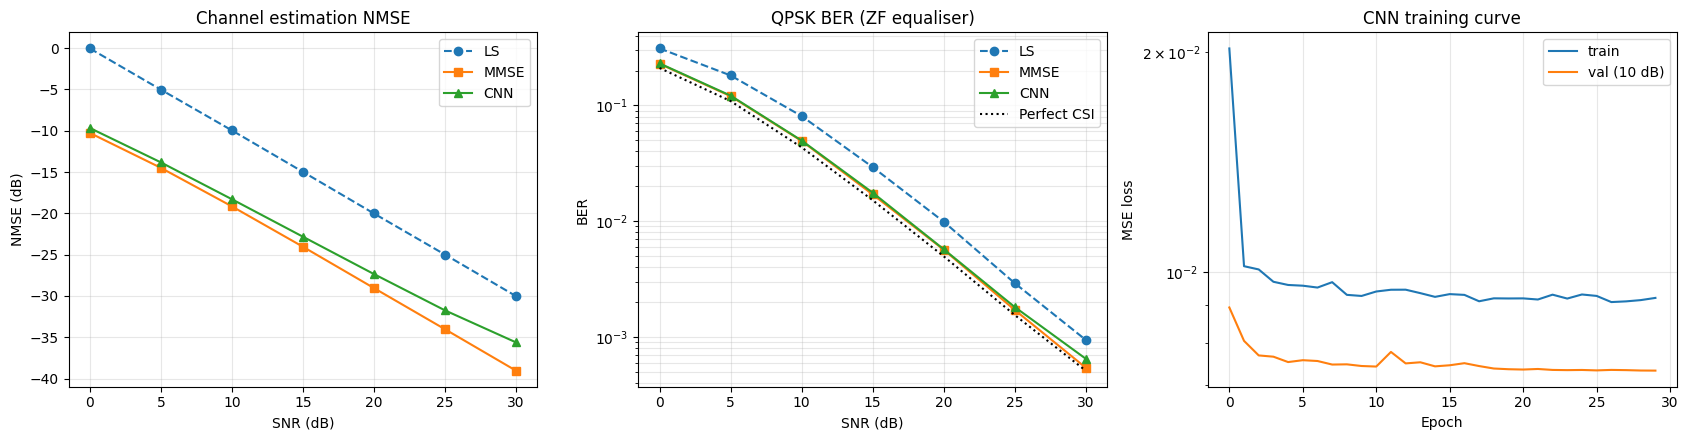

In [6]:
N_TEST = 5000
results = {k: {"nmse": [], "ber": []} for k in ["LS", "MMSE", "CNN", "Perfect CSI"]}
timing = {}

model.eval()
for snr in SNR_TEST:
    H, H_ls, s2 = simulate_pilot(N_TEST, snr)

    t = time.time(); H_mmse = mmse_estimate(H_ls, s2);                      timing["MMSE"] = time.time() - t
    t = time.time(); H_cnn_in = make_input(H_ls, snr).to(device)
    with torch.no_grad():
        H_cnn = to_complex(model(H_cnn_in))
    timing["CNN"] = time.time() - t
    timing["LS"] = 0.0

    ests = {"LS": H_ls, "MMSE": H_mmse, "CNN": H_cnn, "Perfect CSI": H}
    for name, Hh in ests.items():
        results[name]["nmse"].append(nmse(H, Hh))
        results[name]["ber"].append(ber_qpsk(Hh, H, snr))

# ---------------- Plots ----------------
fig, ax = plt.subplots(1, 3, figsize=(17, 4.5))
styles = {"LS": "o--", "MMSE": "s-", "CNN": "^-", "Perfect CSI": "k:"}

for name in ["LS", "MMSE", "CNN"]:
    ax[0].plot(SNR_TEST, 10*np.log10(results[name]["nmse"]), styles[name], label=name)
ax[0].set(xlabel="SNR (dB)", ylabel="NMSE (dB)", title="Channel estimation NMSE"); ax[0].legend(); ax[0].grid(alpha=.3)

for name in results:
    ax[1].semilogy(SNR_TEST, np.maximum(results[name]["ber"], 1e-7), styles[name], label=name)
ax[1].set(xlabel="SNR (dB)", ylabel="BER", title="QPSK BER (ZF equaliser)"); ax[1].legend(); ax[1].grid(alpha=.3, which="both")

h = np.array(history)
ax[2].semilogy(h[:, 0], label="train"); ax[2].semilogy(h[:, 1], label="val (10 dB)")
ax[2].set(xlabel="Epoch", ylabel="MSE loss", title="CNN training curve"); ax[2].legend(); ax[2].grid(alpha=.3)
plt.tight_layout(); plt.show()

In [7]:
rows = []
for i, snr in enumerate(SNR_TEST):
    row = {"SNR (dB)": snr}
    for name in ["LS", "MMSE", "CNN"]:
        row[f"NMSE {name} (dB)"] = round(10*np.log10(results[name]["nmse"][i]), 2)
    for name in results:
        row[f"BER {name}"] = f"{results[name]['ber'][i]:.2e}"
    rows.append(row)
display(pd.DataFrame(rows).set_index("SNR (dB)"))

print(f"\nComplexity / speed (batch of {N_TEST} channels, last SNR point, {device}):")
print(f"  LS    : no parameters, ~0 ms")
print(f"  MMSE  : needs R_hh + SNR (matrix inverse of {N}x{N}), {timing['MMSE']*1e3:.1f} ms")
print(f"  CNN   : {n_params:,} parameters, {timing['CNN']*1e3:.1f} ms")

,NMSE LS (dB),NMSE MMSE (dB),NMSE CNN (dB),BER LS,BER MMSE,BER CNN,BER Perfect CSI
SNR (dB),,,,,,,
0,-0.03,-10.26,-9.66,3.10e-01,2.29e-01,2.30e-01,2.10e-01
5,-5.02,-14.49,-13.83,1.81e-01,1.20e-01,1.21e-01,1.09e-01
10,-9.95,-19.15,-18.29,8.09e-02,4.93e-02,4.97e-02,4.34e-02
15,-14.97,-24.04,-22.82,2.93e-02,1.70e-02,1.76e-02,1.52e-02
20,-20.01,-29.04,-27.35,9.91e-03,5.68e-03,5.73e-03,4.98e-03
25,-24.99,-34.02,-31.74,2.92e-03,1.72e-03,1.82e-03,1.55e-03
30,-30.01,-39.04,-35.62,9.45e-04,5.44e-04,6.50e-04,5.13e-04



Complexity / speed (batch of 5000 channels, last SNR point, cpu):
  LS    : no parameters, ~0 ms
  MMSE  : needs R_hh + SNR (matrix inverse of 64x64), 4.8 ms
  CNN   : 63,298 parameters, 1228.1 ms
